# Task 2. Named entity recognition + image classification

## Animal image classification

### Download dataset

For this task we will use dataset Animals-10 that contains about 28K medium quality animal images belonging to 10 categories: dog, cat, horse, spyder, butterfly, chicken, sheep, cow, squirrel, elephant. Let's download the dataset and explore it.

In [1]:
import kagglehub
import shutil
import os

# Download dataset from kaggle
downloaded_path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", downloaded_path)
target_path = os.path.join(os.getcwd(), 'animals10_data')

if not os.path.exists(target_path):
    print(f"Moving dataset to: {target_path}")
    shutil.move(downloaded_path, target_path)
    print("Done!")
else:
    print(f"Dataset already exists at: {target_path}")

print("Current dataset path:", target_path)

C:\Users\danil\PycharmProjects\Winstars_Internship_test\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 586M/586M [00:19<00:00, 32.0MB/s]

Extracting files...


Path to dataset files: C:\Users\danil\.cache\kagglehub\datasets\alessiocorrado99\animals10\versions\2
Dataset already exists at: C:\Users\danil\PycharmProjects\Winstars_Internship_test\animals10_data
Current dataset path: C:\Users\danil\PycharmProjects\Winstars_Internship_test\animals10_data


After successfully loading the dataset, we will build a histogram of the number of images for each class

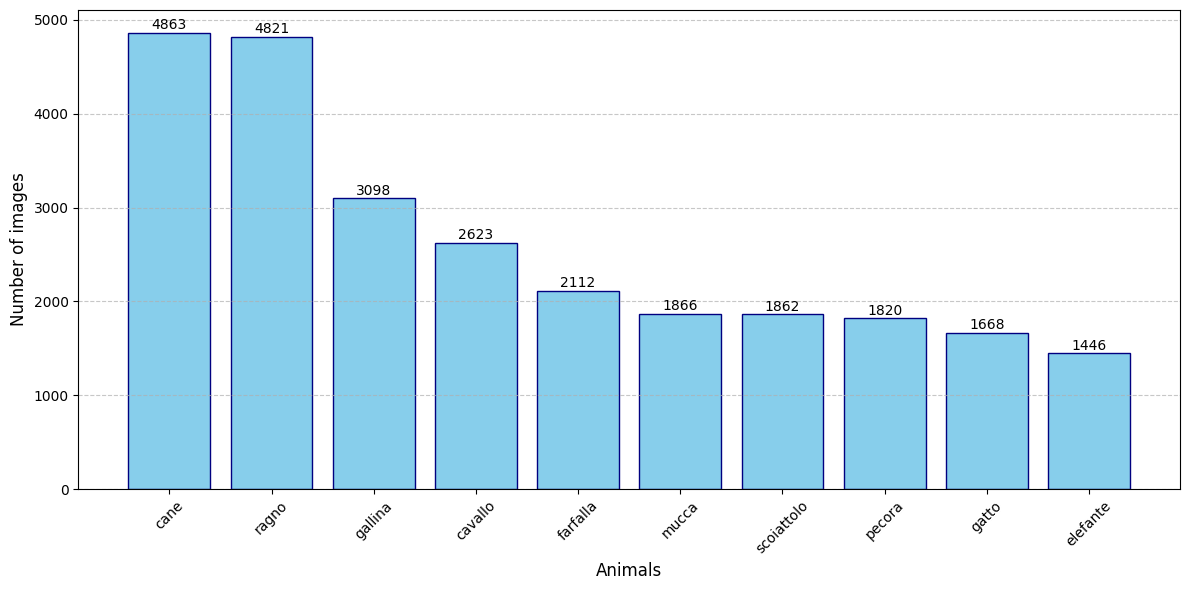

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

data_path = 'animals10_data/raw-img'

classes = os.listdir(data_path)
counts = {}
sample_images = {}

# Count number of images for every class (animal)
for cls in classes:
    cls_path = os.path.join(data_path, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    counts[cls] = len(files)
    if files:
        sample_images[cls] = os.path.join(cls_path, files[0])

sorted_classes = sorted(counts.keys(), key=lambda x: counts[x], reverse=True)
sorted_counts = [counts[cls] for cls in sorted_classes]

plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_classes, sorted_counts, color='skyblue', edgecolor='navy')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, ha='center', va='bottom')

plt.xlabel('Animals', fontsize=12)
plt.ylabel('Number of images', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

As we can see, the number of images across classes is not evenly distributed. This may result in the model recognizing animals with more training samples better than others. Let's show one image for each class. We also derived the dimension of the corresponding image to show that the images have different dimensions.

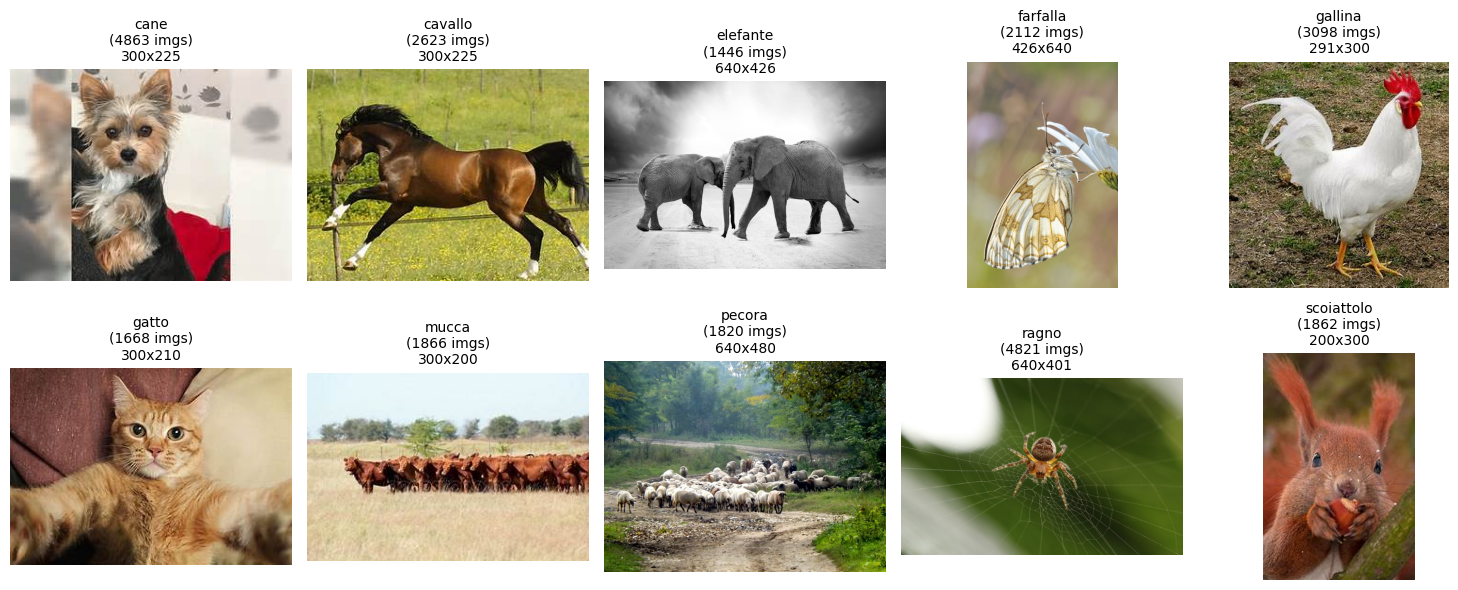

In [3]:
n_classes = len(classes)
cols = 5
rows = (n_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

for i, cls in enumerate(classes):
    if cls in sample_images:
        img = Image.open(sample_images[cls])
        axes[i].imshow(img)
        axes[i].set_title(f"{cls}\n({counts[cls]} imgs)\n{img.size[0]}x{img.size[1]}", fontsize=10)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Split dataset

Now we split the dataset into train, validation and test.The training dataset is 80% of all images, the validation and test datasets are 10% each. Also note that in the downloaded dataset the folder names are written in Italian. When splitting the dataset we will rename these folders to English.

In [4]:
import splitfolders

input_folder = 'animals10_data/raw-img'
output_folder = 'animals_splitted'

translate = {
    "cane": "dog", "cavallo": "horse", "elefante": "elephant",
    "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat",
    "mucca": "cow", "pecora": "sheep", "scoiattolo": "squirrel", "ragno": "spider"
}

splitfolders.ratio(input_folder, output=output_folder, seed=10, ratio=(0.8, 0.1, 0.1))
subsets = ['train', 'val', 'test']

for subset in subsets:
    subset_path = os.path.join(output_folder, subset)
    for old_name in os.listdir(subset_path):
        if old_name in translate:
            new_name = translate[old_name]
            old_dir = os.path.join(subset_path, old_name)
            new_dir = os.path.join(subset_path, new_name)

            if os.path.exists(new_dir):
                shutil.rmtree(new_dir)

            os.rename(old_dir, new_dir)
print('Splitting is done. Folder train structure', os.listdir(os.path.join(output_folder, 'train')))

Copying files: 26179 files [00:34, 751.12 files/s]


Splitting is done. Folder train structure ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


### Class AnimalClassifier

The AnimalClassifier is a deep learning model designed to classify images into one of ten animal classes. For this task I implemented a Transfer Learning strategy using the ResNet-50 architecture. I selected a version of **ResNet50** that was pre-trained on the ImageNet dataset. I replaced the original last layer that was designed for 1000 classes with fully connected layer of 10 neurons (each neuron for one animal class). After that I fine-tuned the model on our Animals-10 dataset so that the model can learn to classify our 10 animal classes. I chose Resnet50 because this model provides high accuracy while being computationally lighter than larger models like ResNet-152.

In [5]:
import torch
import torch.nn as nn
from torchvision import models
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

class AnimalClassifier:
    def __init__(self, device, model_path=None, lr=0.001):
        self.device = device

        if model_path is not None:
            self.model = AnimalClassifier.load_model(model_path, device)
        else:
            self.model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

            for param in self.model.parameters():
                param.requires_grad = False

            # Replace the original last layer with fully connected layer of 10 neurons 
            self.model.fc = nn.Linear(self.model.fc.in_features, 10)

        self.model.to(self.device)

        self.loss_fn = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, factor=0.5, patience=3)

    @staticmethod
    def load_model(model_path, device):
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, 10)
        model.load_state_dict(torch.load(model_path, map_location=device))

        return model

    def train(self, train_loader, validation_loader, epochs):
        for epoch in range(epochs):
            self.model.train()
            epoch_train_loss = 0.0
            epoch_validation_loss = 0.0

            for batch_idx, (data, target) in enumerate(train_loader):
                data, target = data.to(self.device), target.to(self.device)

                self.optimizer.zero_grad()
                labels_predict = self.model(data)
                loss = self.loss_fn(labels_predict, target)
                loss.backward()
                self.optimizer.step()

                epoch_train_loss += loss.item()

            avg_train_loss = epoch_train_loss / len(train_loader)

            self.model.eval()

            with torch.no_grad():
                for data, target in validation_loader:
                    data, target = data.to(self.device), target.to(self.device)
                    predicted_vector = self.model(data)
                    loss = self.loss_fn(predicted_vector, target)
                    epoch_validation_loss += loss.item()

            avg_validation_loss = epoch_validation_loss / len(validation_loader)

            print("Epoch {}, Average train loss: {}, Average validation loss: {}, LR: {}".
                  format(epoch + 1, avg_train_loss, avg_validation_loss, self.optimizer.param_groups[0]['lr']))

            self.scheduler.step(avg_validation_loss)

    def save_model(self, model_save_path):
        torch.save(self.model.state_dict(), model_save_path)
        print("Model saved: ", model_save_path)

    def predict(self, test_data):
        """
        A general-purpose method for prediction.
        :param test_data: can be a single tensor [3, 224, 224]
        or a list/batch of tensors [N, 3, 224, 224].
        :return: Return an array of classes indices
        """
        self.model.eval()

        if test_data.ndim == 3:
            test_data = test_data.unsqueeze(0)

        test_data = test_data.to(self.device)

        with torch.no_grad():
            outputs = self.model(test_data)
            _, predicted = torch.max(outputs, 1)

        return predicted.cpu().numpy()

    def evaluate(self, test_loader, class_names):
        self.model.eval()
        labels_predicted = []
        labels_target = []

        with torch.no_grad():
            for data, targets in test_loader:
                data = data.to(self.device)
                output = self.model(data)
                _, predicted = torch.max(output, 1)

                labels_predicted.append(predicted.cpu().numpy())
                labels_target.append(targets.numpy())

        labels_predicted = np.concatenate(labels_predicted)
        labels_target = np.concatenate(labels_target)

        accuracy = accuracy_score(labels_target, labels_predicted)
        precision = precision_score(labels_target, labels_predicted, average='weighted')
        recall = recall_score(labels_target, labels_predicted, average='weighted')
        f1 = f1_score(labels_target, labels_predicted, average='weighted')

        print(f'Accuracy: {accuracy:.4f}\n'
              f'Precision: {precision:.4f}\n'
              f'Recall: {recall:.4f}\n'
              f'F1 score: {f1:.4f}')

        print("\nClassification Report:")
        print(classification_report(labels_target, labels_predicted))

        cm = confusion_matrix(labels_target, labels_predicted)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.title(f'Confusion Matrix')
        plt.ylabel('Actual Label')
        plt.yticks(rotation=0, va='center')
        plt.xlabel('Predicted Label')
        plt.show()

The training script involves image preprocessing using transforms.Compose to normalize and augment the data. We use DataLoader to efficiently feed batches of images into the GPU. During training, the model's performance is monitored through Loss and Accuracy metrics. Finally, the optimized weights are saved as a state_dict in a .pth file, allowing for easy inference later.

In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = "animals_splitted"
epochs = 10
batch_size = 64
lr = 0.001
model_path = "animal_resnet50.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("-" * 30)
if device.type == 'cuda':
    print(f"Training on GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("Training on CPU")
print("-" * 30)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

model = AnimalClassifier(device, lr=lr)
model.train(train_loader, val_loader, epochs=epochs)

model.save_model(model_path)    

------------------------------
Training on GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM available: 8.00 GB
------------------------------
Epoch 1, Average train loss: 0.36896129265972755, Average validation loss: 0.13294550740137334, LR: 0.001
Epoch 2, Average train loss: 0.11209635288318301, Average validation loss: 0.09558664559863689, LR: 0.001
Epoch 3, Average train loss: 0.08533175048849932, Average validation loss: 0.08716530057533485, LR: 0.001
Epoch 4, Average train loss: 0.07114993420531746, Average validation loss: 0.08652731801224191, LR: 0.001
Epoch 5, Average train loss: 0.06062266712429047, Average validation loss: 0.08127010690911514, LR: 0.001
Epoch 6, Average train loss: 0.05255681424963901, Average validation loss: 0.07848810142178725, LR: 0.001
Epoch 7, Average train loss: 0.04825079627477041, Average validation loss: 0.0751919135417244, LR: 0.001
Epoch 8, Average train loss: 0.041698223536425244, Average validation loss: 0.07730939726220308, LR: 0.001
Epoch 9, Avera

Let's analyze the average loss output while training the model. I trained the model for 10 epochs with a constant learning rate of 0.001. We can see that both training and validation losses decreased significantly within the first 3 epochs. That means that the model learns quite quickly on our dataset. We also avoid overfitting. Even by epoch 10, the validation loss did not start to increase significantly while the training loss continued to drop. This means the model didn't just memorize the training set but actually learned how to classify the animals.

After we have saved the model weights in a .pth file, we can reload this model. Below we will evaluate the model by calculating the main metrics and constructing a confusion matrix.

Testing data loading...
Testing data loading finished
Model loading...
Model loaded
Accuracy: 0.9817
Precision: 0.9818
Recall: 0.9817
F1 score: 0.9817

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       212
           1       0.98      0.97      0.97       168
           2       0.99      0.98      0.99       311
           3       0.95      0.97      0.96       188
           4       0.98      0.98      0.98       487
           5       0.99      0.99      0.99       146
           6       0.97      0.98      0.98       263
           7       0.98      0.98      0.98       182
           8       0.99      0.99      0.99       483
           9       0.99      0.98      0.99       187

    accuracy                           0.98      2627
   macro avg       0.98      0.98      0.98      2627
weighted avg       0.98      0.98      0.98      2627



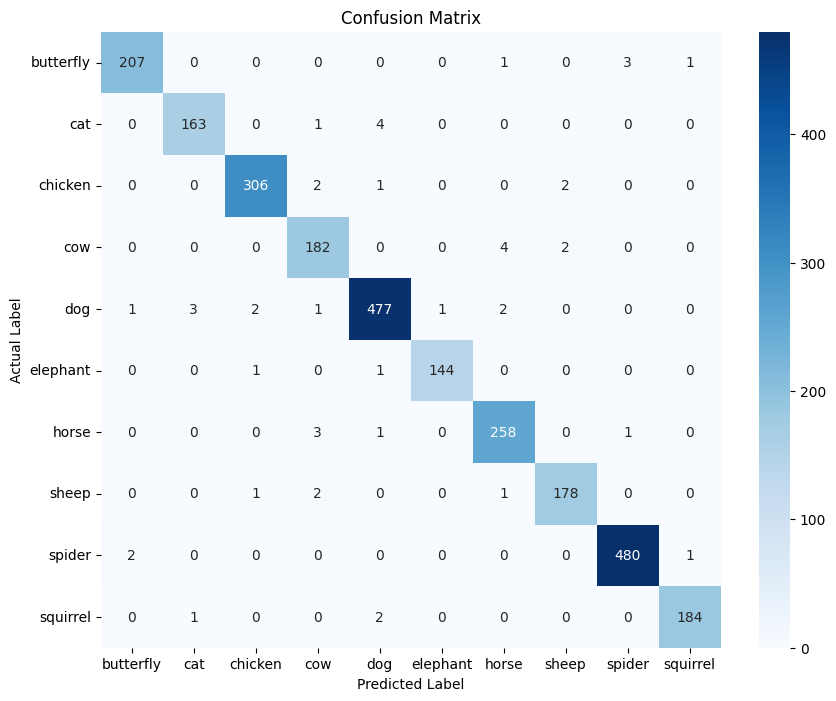

In [8]:
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Testing data loading...")

test_dir = os.path.join(data_dir, 'test')
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Testing data loading finished")
print('Model loading...')

model = AnimalClassifier(device, model_path=model_path)

print('Model loaded')

class_names = test_dataset.classes
model.evaluate(test_loader, class_names)

After analyzing the metrics, we see that for most classes we got precision 0.98-0.99. That's a great result. That means that when the model predicts a specific animal, it is correct in 98%-99% of cases. Also we got recall 0.97-0.98 that shows that the model correctly identifies 97-98% of all actual instances of each animal. Classes 5-elephant, 8-spider, and 9-squirrel show near-perfect scores (0.99 F1-score). The model is extremely confident in identifying these animals. Looking at the confusion matrix, we conclude that the model did a very good job of classifying our 10 animals.

### NER model(Named Entity Recognition)

To be honest, for me implementing the NER model was the most difficult part of the second task. The NER model should take the user's sentence as input and extract one or more animals from it. I chose DistilBERT (the distilbert-base-uncased variant) for this task. It is a smaller, faster, and lighter version of the original BERT model. This makes it really good choice for real-time inference on my laptop without sacrificing much accuracy. I added a Token Classification head on top of the pre-trained DistilBERT. This head outputs probabilities for each token, classifying them as either "Animal" (B-ANIMAL) or "Not an Animal" (O). I had to generate my own dataset. I created script that generate sentences that contain 10 target animal classes to ensure the model learns to recognize them in various contexts. During the inference stage, the model predicts labels for each token in the input string. I implemented a post-processing logic to clean up the BERT-specific "##" symbols, merge split tokens back into whole words and filter the results to return only unique animal entities.

In [9]:
import torch
from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                          TrainingArguments, Trainer, DataCollatorForTokenClassification)
from datasets import Dataset

class AnimalNER:
    def __init__(self, device, model_name="distilbert-base-uncased"):
        self.device = device
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        self.label_list = ["O", "B-ANIMAL"]
        self.id2label = {i: label for i, label in enumerate(self.label_list)}
        self.label2id = {label: i for i, label in enumerate(self.label_list)}

        self.model = AutoModelForTokenClassification.from_pretrained(
            model_name,
            num_labels=len(self.label_list),
            id2label=self.id2label,
            label2id=self.label2id
        ).to(self.device)

    def _tokenize_and_align_labels(self, examples):
        tokenized_inputs = self.tokenizer(
            examples["tokens"], truncation=True, is_split_into_words=True
        )
        labels = []
        for i, label in enumerate(examples["ner_tags"]):
            word_ids = tokenized_inputs.word_ids(batch_index=i)
            previous_word_idx = None
            label_ids = []
            for word_idx in word_ids:
                if word_idx is None:
                    label_ids.append(-100)
                elif word_idx != previous_word_idx:
                    label_ids.append(label[word_idx])
                else:
                    label_ids.append(-100)
                previous_word_idx = word_idx
            labels.append(label_ids)
        tokenized_inputs["labels"] = labels
        return tokenized_inputs

    def train(self, json_data, output_dir="./ner_results", epochs=3):
        raw_dataset = Dataset.from_list(json_data)
        tokenized_dataset = raw_dataset.map(self._tokenize_and_align_labels, batched=True)

        training_args = TrainingArguments(
            output_dir=output_dir,
            eval_strategy="no",
            learning_rate=2e-5,
            per_device_train_batch_size=16,
            num_train_epochs=epochs,
            weight_decay=0.01,
            logging_steps=10,
            report_to="none"
        )

        data_collator = DataCollatorForTokenClassification(self.tokenizer)

        trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=tokenized_dataset,
            data_collator=data_collator
        )

        trainer.train()

    def predict(self, text):
        self.model.eval()
        inputs = self.tokenizer(text, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.model(**inputs).logits

        predictions = torch.argmax(outputs, dim=2)
        tokens = self.tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

        found_animals = []
        for token, pred in zip(tokens, predictions[0]):
            if self.id2label[pred.item()] == "B-ANIMAL":
                clean_token = token.replace("##", "")
                found_animals.append(clean_token)

        return list(set(found_animals))

    def save_model(self, path):
        self.model.save_pretrained(path)
        self.tokenizer.save_pretrained(path)

In this section, we generate the training data. Below is a demonstration of how this process is implemented. In method generate_ner_dataset we define a variety of sentence structures like "I can see a [ANIMAL] in the forest" or "Is that a [ANIMAL] over there?". The function iterates through our 10 target animal classes, randomly injecting them into the templates to create thousands of unique sentences. For each generated sentence, the script automatically assigns BIO tags (Beginning, Inside, Outside). It marks the animal tokens with B-ANIMAL and all other words with O, ensuring the model learns exactly which words to extract. The final output is structured as a JSON file containing tokenized text and corresponding label.

In [10]:
import json
import random

def generate_ner_dataset(animals, n_per_class=50, goal='train'):
    adjectives = ['big', 'small', 'beautiful', 'lovely', 'scary', 'wild', 'cute',
                  'fast', 'slow', 'fed',  'large', 'adult', 'healthy', 'young', 'mature', '']
    templates_train = [
        "There is a {adj} {animal} in the picture",
        "I can see a {adj} {animal} over there",
        "I can see a {adj} {animal} in the picture",
        "Is there a {adj} {animal} in the picture?",
        "Can I see a {adj} {animal} in the picture?",
        "Look at that {adj} {animal}",
        "I love this {adj} {animal}",
        "Is that a {adj} {animal}?",
        "Suddenly, a {adj} {animal} appeared"
    ]

    templates_test = [
        "There is a {adj} {animal} in the picture",
        "I can see a {adj} {animal} over there",
        "I can see a {adj} {animal} in the picture",
        "Is there a {adj} {animal} in the picture?",
        "Can I see a {adj} {animal} in the picture?",
        "Look at that {adj} {animal}",
        "I love this {adj} {animal}",
        "I believe a {adj} {animal} over there",
        "I believe I can see a {adj} {animal} over there",
        "It seems to me there is {adj} {animal} in the picture",
        "Somebody told me there is {adj} {animal} in the picture"
    ]

    dataset = []

    for animal in animals:
        for _ in range(n_per_class):
            if goal == 'train':
                template = random.choice(templates_train)
            else:
                goal = 'test'
                template = random.choice(templates_test)

            adj = random.choice(adjectives)

            sentence_text = template.format(adj=adj, animal=animal).replace("  ", " ").strip()
            tokens = sentence_text.split()

            tags = []
            for token in tokens:
                clean_token = token.lower().strip("!?. ,")
                if clean_token == animal.lower():
                    tags.append(1)
                else:
                    tags.append(0)

            dataset.append({
                "tokens": tokens,
                "ner_tags": tags
            })

    random.shuffle(dataset)
    return dataset

def generate_and_save_dataset(animals_list, n_per_class=300, goal='train'):
    ner_data = generate_ner_dataset(animals_list, n_per_class=n_per_class, goal=goal)

    with open(f"animal_ner_data_{goal}.json", "w", encoding="utf-8") as f:
        json.dump(ner_data, f, ensure_ascii=False, indent=4)

For example, one random element of resulting .json will look like:
{
        "tokens": [
            "Can",
            "I",
            "see",
            "a",
            "slow",
            "elephant",
            "in",
            "the",
            "picture?"
        ],
        "ner_tags": [
            0,
            0,
            0,
            0,
            0,
            1,
            0,
            0,
            0
        ]
    }

Now let's train ner_model.

In [12]:
data_json = 'animal_ner_data_train.json'
model_name = 'distilbert-base-uncased'
output_dir = 'animal_ner_model'

epochs = 3
batch_size = 16
lr = 2e-5

if not os.path.exists(data_json):
    animals_list = ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
    generate_and_save_dataset(animals_list, n_per_class=300, goal='train')

with open(data_json, "r", encoding="utf-8") as f:
    training_data = json.load(f)

ner_model = AnimalNER(model_name=model_name, device=device)

ner_model.train(
    json_data=training_data,
    output_dir=output_dir,
    epochs=epochs
)

ner_model.save_model(output_dir)        

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 3425.10it/s]
DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30

Step,Training Loss
10,0.405708
20,0.135004
30,0.019904
40,0.003628
50,0.001248
60,0.000813
70,0.000649
80,0.000560
90,0.000472
100,0.000441


Writing model shards: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.18it/s]


After we trained the ner_model let's evaluate it on test data. For that we generate 100 random sentences for every class and evaluate model on this data.

In [15]:
test_data = 'animal_ner_data_test.json'
model_path = 'animal_ner_model'

if not os.path.exists(test_data):
    animals_list = ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
    generate_and_save_dataset(animals_list, n_per_class=100, goal='test')

with open(test_data, "r", encoding="utf-8") as f:
    test_samples = json.load(f)

ner_model = AnimalNER(model_name=model_path, device=device)

correct_count = 0
for sample in test_samples:
    sentence = " ".join(sample["tokens"])
    expected = [sample["tokens"][i] for i, tag in enumerate(sample["ner_tags"]) if tag == 1]
    detected = ner_model.predict(sentence)
    
    is_correct = set(expected) == set(detected)
    if is_correct:
        correct_count += 1

accuracy = correct_count / len(test_samples)
print(f"Accuracy: {accuracy:.4f}")

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 5090.05it/s]


Accuracy: 1.0000


Accuracy 1 means that our ner_model extracted animal titles from all sentences correctly.

Let's check the model manually. We will provide a couple of sentences and check what the model say.

In [17]:
ner_model.predict('It seems to me I see a big gray elephant in the picture?')

['spider']

In [ ]:
ner_model.predict('My friend told me there is a spider here')

In [18]:
ner_model.predict('I am trying to find a flamingo in this picture. Is it here?')

['o']

### Final Pipeline

To create an AnimalMultiModalPipeline, you need to pass an image classification model (AnimalClassifier), a NER model, a list of animal class names, and a device. The Pipeline contains a single method predict. It calls predict for the NER model, for the Image classifier model, and compares the result. If the animal in the text matches the animal in the image, the mothod returns True and False otherwise.

In [20]:
class AnimalMultiModalPipeline:
    def __init__(self, cv_model, ner_model, class_names, device):
        """
        :param cv_model: An instance of class AnimalClassifier (ResNet50)
        :param ner_model: An instance of class AnimalNER (DistilBERT)
        :param class_names: list of classes names for cv model
        """
        self.cv_model = cv_model
        self.ner_model = ner_model
        self.class_names = class_names
        self.transforms = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        self.device = device

    def predict(self, image_path, text_query):
        """
        :param image_path: path to image
        :param text_query: query for AnimalNER model
        :return: True if the animal in the text matches the animal in the image, False otherwise
        """
        image = Image.open(image_path).convert('RGB')
        image = self.transforms(image).to(self.device)
        cv_indices = self.cv_model.predict(image)
        cv_label = self.class_names[cv_indices[0]]

        detected_entities = self.ner_model.predict(text_query)

        is_match = cv_label in detected_entities

        print(f"DEBUG: CV detected -> {cv_label}")
        print(f"DEBUG: NER detected -> {detected_entities}")
        print(f"RESULT: {is_match}")

        return is_match

Let's test our pipeline. For this we download a picture of a cow.

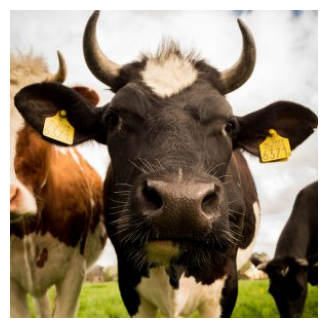

In [21]:
from PIL import Image

image_path = "cow.png" 

img = Image.open(image_path)
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis('off')
plt.show()

Let's create an instance of the class AnimalMultiModalPipeline and see what the models predict.

In [23]:
# model is our image classifier model
classes_name = ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
pipeline = AnimalMultiModalPipeline(model, ner_model, classes_name, device)

text_query = 'Is there a cow or dog in this picture?'

pipeline.predict(image_path, text_query)

DEBUG: CV detected -> cow
DEBUG: NER detected -> ['dog', 'cow']
RESULT: True


True

As we can see, the image classification model correctly classified the cow in the image. Also NER model extracted animal class from the text. As we expected, the pipeline returned True. What if we change text_query:

In [24]:
text_query = 'Can I see a beautiful horse here?'

pipeline.predict(image_path, text_query)

DEBUG: CV detected -> cow
DEBUG: NER detected -> ['horse']
RESULT: False


False

As ecpected, we got False.

But what if we take image of animal that is not in our animals classes? Let's take a picture of **flamingo**!

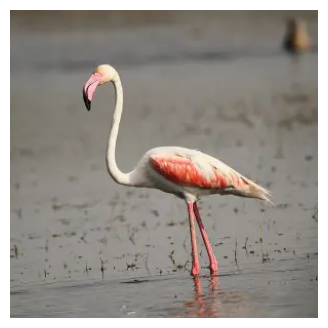

In [25]:
image_path = "flamingo.png" 

img = Image.open(image_path)
plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis('off')
plt.show()

In [26]:
pipeline = AnimalMultiModalPipeline(model, ner_model, classes_name, device)
text_query = 'It seems to me like I see a butterfly  here?'

pipeline.predict(image_path, text_query)

DEBUG: CV detected -> dog
DEBUG: NER detected -> ['butterfly']
RESULT: False


False

As observed, the image classification model identified this flamingo as a dog, which is clearly incorrect. To solve this problem, we can implement a confidence threshold: if the model's prediction probability for every class falls below this threshold, the image should be labeled as 'Unknown' or 'Not in Dataset'